In [25]:
# Macro-Average ROC Comparison Notebook

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [26]:
#Load Predictions and Labels for Each Model

# Resnet
#y_true_resnet = np.load("y_true_resnet.npy")
#y_pred_resnet = np.load("y_pred_resnet.npy")

#Transformer
#y_true_transformer = np.load("y_true_transformer.npy")
#y_pred_transformer = np.load("y_pred_transformer.npy")

# XResNet
y_true_xresnet = np.load("y_true_xresnet.npy")
y_pred_xresnet = np.load("y_pred_xresnet.npy")

# XLSTM
y_true_xlstm = np.load("y_true_xlstm.npy")
y_pred_xlstm = np.load("y_pred_xlstm.npy")

# Hybrid
y_true_hybrid = np.load("y_true_hybrid.npy")
y_pred_hybrid = np.load("y_pred_hybrid.npy")

In [28]:
# === Step 2: Define Macro-Average ROC Calculator ===
def compute_macro_roc(y_true, y_pred):
    n_classes = y_true.shape[1]
    fpr_dict, tpr_dict = {}, {}

    for i in range(n_classes):
        fpr_dict[i], tpr_dict[i], _ = roc_curve(y_true[:, i], y_pred[:, i])

    all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)

    return all_fpr, mean_tpr, macro_auc

In [29]:
# === Step 3: Compute Macro ROC Curves ===
#fpr_resnet, tpr_resnet, roc_auc_resnet = compute_macro_roc(y_true_resnet, y_pred_resnet)
#fpr_transformer, tpr_transformer, roc_auc_transformer = compute_macro_roc(y_true_transformer, y_pred_transformer)
fpr_xresnet, tpr_xresnet, roc_auc_xresnet = compute_macro_roc(y_true_xresnet, y_pred_xresnet)
fpr_xlstm, tpr_xlstm, roc_auc_xlstm = compute_macro_roc(y_true_xlstm, y_pred_xlstm)
fpr_hybrid, tpr_hybrid, roc_auc_hybrid = compute_macro_roc(y_true_hybrid, y_pred_hybrid)

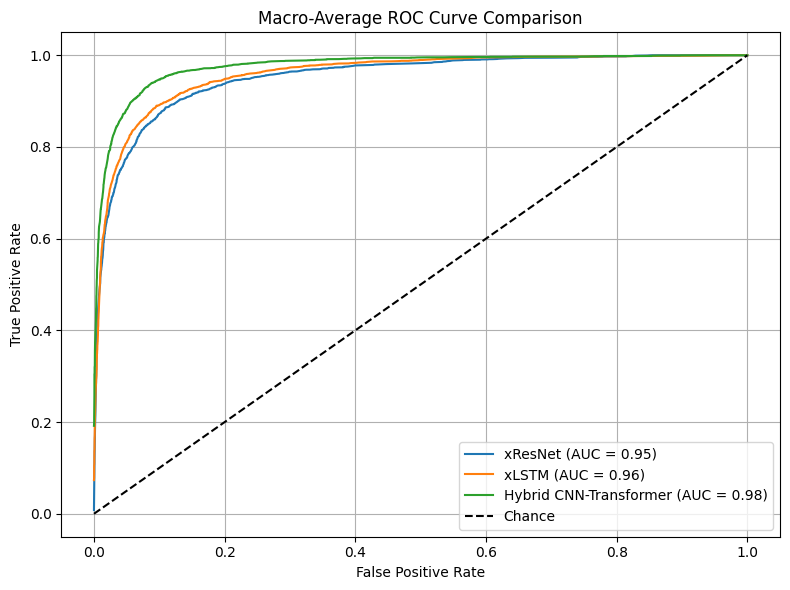

In [33]:
plt.figure(figsize=(8, 6))

# XResNet
plt.plot(fpr_xresnet, tpr_xresnet, label=f"xResNet (AUC = {roc_auc_xresnet:.2f})")
# XLSTM
plt.plot(fpr_xlstm, tpr_xlstm, label=f"xLSTM (AUC = {roc_auc_xlstm:.2f})")
# Hybrid (CNN + Transformer)
plt.plot(fpr_hybrid, tpr_hybrid, label=f"Hybrid CNN-Transformer (AUC = {roc_auc_hybrid:.2f})")
# Chance line
plt.plot([0, 1], [0, 1], 'k--', label="Chance")
# Formatting
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Macro-Average ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig("macro_roc_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()